Saved extracted data as extracted_graph_data.csv
            X      Y  Distance_from_Origin    Class  Slope  Curvature  \
503 -7.850746  0.656              7.878106  sin.png  0.000        0.0   
504 -7.850746  0.648              7.877444  sin.png   -inf        0.0   
420 -7.820896  0.424              7.832380  sin.png -7.504        inf   
419 -7.820896  0.432              7.832818  sin.png    inf        inf   
413 -7.820896  0.472              7.835125  sin.png    inf        0.0   

     Angle_with_X_Axis  
503           0.000000  
504         -90.000000  
420         -82.409358  
419          90.000000  
413          90.000000  


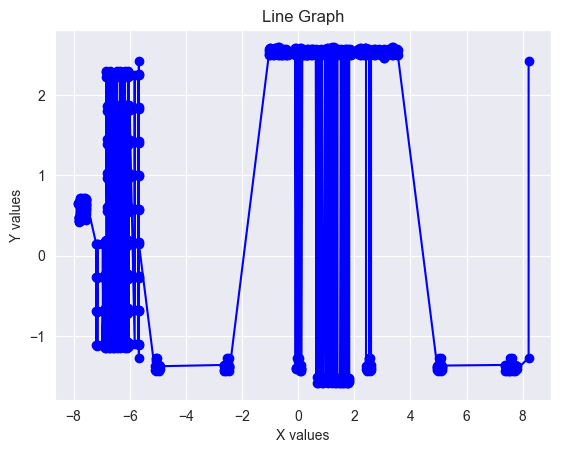

In [11]:
import cv2
import numpy as np
import pandas as pd
import math
import matplotlib.pyplot as plt

def plot_graph(x,y):
    plt.plot(x, y, marker='o', linestyle='-', color='b', label='Data')
    plt.xlabel('X values')
    plt.ylabel('Y values')
    plt.title('Line Graph')
    # plt.grid(True)
    # plt.legend()

    # Display the graph
    plt.show()



def extract_graph_data(image_path, graph_x_range=(-5, 5), graph_y_range=(-10, 10), save_csv=True):
    # Load image in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    # Apply adaptive thresholding for better edge detection
    thresh = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 11, 2)

    # Detect edges
    edges = cv2.Canny(thresh, 50, 150)

    # Detect axes using Hough Transform
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100, minLineLength=50, maxLineGap=5)
    if lines is None:
        raise ValueError("No lines detected. Ensure the graph has clear axes.")

    width, height = img.shape[1], img.shape[0]
    x_axis_y, y_axis_x = None, None

    # Identify X and Y axes
    for line in lines:
        x1, y1, x2, y2 = line[0]
        if abs(y1 - y2) < 10:  # Horizontal line (X-axis)
            x_axis_y = y1
        if abs(x1 - x2) < 10:  # Vertical line (Y-axis)
            y_axis_x = x1


    if x_axis_y is None or y_axis_x is None:
        raise ValueError("Could not detect the axes. Ensure the graph is clear.")

    # Compute scale factors
    x_scale = (graph_x_range[1] - graph_x_range[0]) / (width - y_axis_x)
    y_scale = (graph_y_range[1] - graph_y_range[0]) / (x_axis_y)

    # Find contours of the plotted graph
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    data_points = []
    image_name = image_path.split('/')[-1]  # Extract image name from path
    for cnt in contours:
        for point in cnt:
            px, py = point[0]  # Pixel coordinates
            # Convert pixel coordinates to real graph values
            real_x = graph_x_range[0] + ((px - y_axis_x) * x_scale)
            real_y = graph_y_range[1] - ((py - x_axis_y) * y_scale)

            # Distance from origin (r = sqrt(x^2 + y^2))
            distance_from_origin = math.sqrt(real_x**2 + real_y**2)

            data_points.append((real_x, real_y, distance_from_origin, image_name))

    # Convert to DataFrame and remove duplicates
    df = pd.DataFrame(data_points, columns=["X", "Y", "Distance_from_Origin", "Class"]).drop_duplicates().sort_values(by=["X"])

    # Estimate slope and curvature
    df['Slope'] = df['Y'].diff() / df['X'].diff()
    df['Curvature'] = df['Slope'].diff() / df['X'].diff()

    # Calculate angle with respect to X-axis
    df['Angle_with_X_Axis'] = np.arctan(df['Slope']) * (180 / np.pi)

    # Replace NaN values with 0
    df = df.fillna(0)

    if save_csv:
        df.to_csv(f"extracted_graph_data_{image_name}.csv", index=False)
        print("Saved extracted data as extracted_graph_data.csv")

    return df

# Example Usage
df = extract_graph_data("sin.png", graph_x_range=(0, 10), graph_y_range=(-1,1))
print(df.head())  # Check extracted data

plot_graph(np.array(df['X']),np.array(df['Y']) )
# print(df['Y'])
